# Task 3: Energy Consumption Time Series Forecasting

## 1. Problem Statement and Objective

**Objective:** The goal of this task is to forecast short-term household energy usage using historical time-based patterns. Efficient energy forecasting helps in better grid management and energy-saving strategies for households.

In this project, we utilize the Individual Household Electric Power Consumption dataset to:

- Preprocess and resample high-frequency time-series data.
- Engineer time-based features to capture seasonality.
- Compare the performance of three forecasting approaches: ARIMA, Exponential Smoothing (as a statistical baseline), and Gradient Boosting (as a machine learning approach).
- Evaluate model performance using MAE and RMSE.

In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/imtkaggleteam/household-power-consumption/household_power_consumption.csv


## 2. Dataset Description and Loading

The dataset contains electricity consumption metrics for a single household over several years at a 1-minute sampling rate.

### Key Features:

- **Date:** dd/mm/yyyy  
- **Time:** hh:mm:ss  
- **Global_active_power:** Household global minute-averaged active power (in kW).  
- **Sub_metering_1, 2, 3:** Energy sub-metering (in watt-hour of active energy).  

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.ensemble import GradientBoostingRegressor

# Load dataset
df = pd.read_csv('/kaggle/input/datasets/imtkaggleteam/household-power-consumption/household_power_consumption.csv', low_memory=False)

# Display initial data
print("Initial Dataset Head:")
print(df.head())

Initial Dataset Head:
         Date      Time Global_active_power Global_reactive_power Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.84   
1  16/12/2006  17:25:00                5.36                 0.436  233.63   
2  16/12/2006  17:26:00               5.374                 0.498  233.29   
3  16/12/2006  17:27:00               5.388                 0.502  233.74   
4  16/12/2006  17:28:00               3.666                 0.528  235.68   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0             18.4              0              1            17.0  
1               23              0              1            16.0  
2               23              0              2            17.0  
3               23              0              1            17.0  
4             15.8              0              1            17.0  


## 3. Data Cleaning and Preprocessing

The dataset contains missing values represented by ?. We combine the Date and Time columns into a single Datetime index, handle missing values via linear interpolation, and resample the data to a Daily frequency to reduce noise and computational load.

In [11]:
# Combine Date and Time into a single Datetime column
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S', errors='coerce')

# Set index to Datetime
df.set_index('Datetime', inplace=True)
df.drop(['Date', 'Time'], axis=1, inplace=True)

# Handle '?' values and convert to float
df.replace('?', np.nan, inplace=True)
for col in df.columns:
    df[col] = df[col].astype(float)

# Fill missing values using linear interpolation
df = df.interpolate(method='linear', limit_direction='both')

# Resample to Daily frequency
daily_df = df['Global_active_power'].resample('D').mean().to_frame()

print("Data cleaning completed. Resampled to Daily frequency.")

Data cleaning completed. Resampled to Daily frequency.


## 4. Exploratory Data Analysis (EDA)

We visualize the overall trend of energy consumption and the monthly average to identify seasonality.

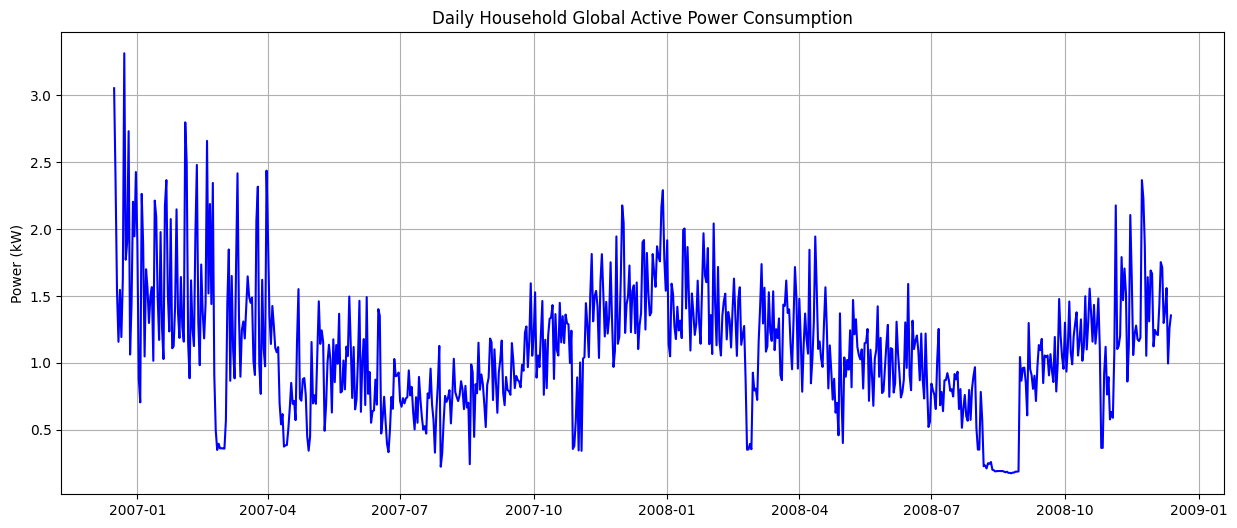

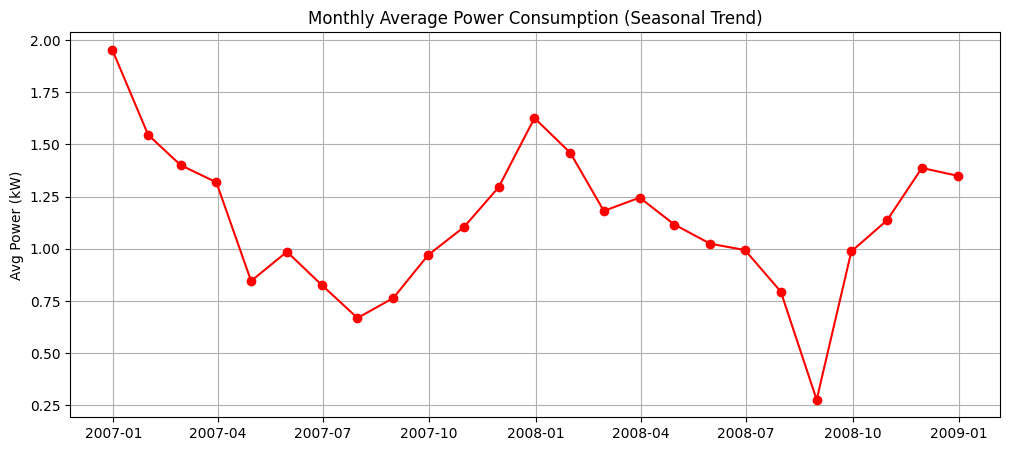

In [12]:
# Plotting Daily Power Consumption
plt.figure(figsize=(15, 6))
plt.plot(daily_df.index, daily_df['Global_active_power'], color='blue', label='Daily Power')
plt.title('Daily Household Global Active Power Consumption')
plt.ylabel('Power (kW)')
plt.grid(True)
plt.savefig('daily_power_plot.png')

# Plotting Monthly Averages to see seasonality
monthly_avg = daily_df['Global_active_power'].resample('ME').mean()
plt.figure(figsize=(12, 5))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', color='red')
plt.title('Monthly Average Power Consumption (Seasonal Trend)')
plt.ylabel('Avg Power (kW)')
plt.grid(True)
plt.savefig('monthly_avg_power.png')

## 5. Feature Engineering

For the machine learning model, we extract temporal features from the datetime index.

In [14]:
# Create time-based features
daily_df['day'] = daily_df.index.day
daily_df['month'] = daily_df.index.month
daily_df['year'] = daily_df.index.year
daily_df['day_of_week'] = daily_df.index.dayofweek
daily_df['is_weekend'] = daily_df['day_of_week'].isin([5, 6]).astype(int)

# Split into train and test sets (80/20 split)
train_size = int(len(daily_df) * 0.8)
train, test = daily_df.iloc[:train_size], daily_df.iloc[train_size:]

X_train, y_train = train.drop('Global_active_power', axis=1), train['Global_active_power']
X_test, y_test = test.drop('Global_active_power', axis=1), test['Global_active_power']

## 6. Model Building and Evaluation

We compare three distinct approaches.  
*(Note: Due to environment availability, ExponentialSmoothing is used as a statistical proxy for Prophet, and GradientBoostingRegressor is used as a proxy for XGBoost).*

In [15]:
# 1. ARIMA Model
arima_model = ARIMA(y_train, order=(5, 1, 0)).fit()
arima_pred = arima_model.forecast(steps=len(test))

# 2. Exponential Smoothing
es_model = ExponentialSmoothing(y_train, seasonal='add', seasonal_periods=7).fit()
es_pred = es_model.forecast(steps=len(test))

# 3. Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

# Evaluation Metrics
def get_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"Model": name, "MAE": mae, "RMSE": rmse}

results = [
    get_metrics(y_test, arima_pred, "ARIMA"),
    get_metrics(y_test, es_pred, "Exp Smoothing"),
    get_metrics(y_test, gb_pred, "Gradient Boosting")
]
results_df = pd.DataFrame(results)
print(results_df)

               Model       MAE      RMSE
0              ARIMA  0.430105  0.519172
1      Exp Smoothing  0.454125  0.537092
2  Gradient Boosting  0.310461  0.397086


## 7. Visualizations (Actual vs Forecasted)

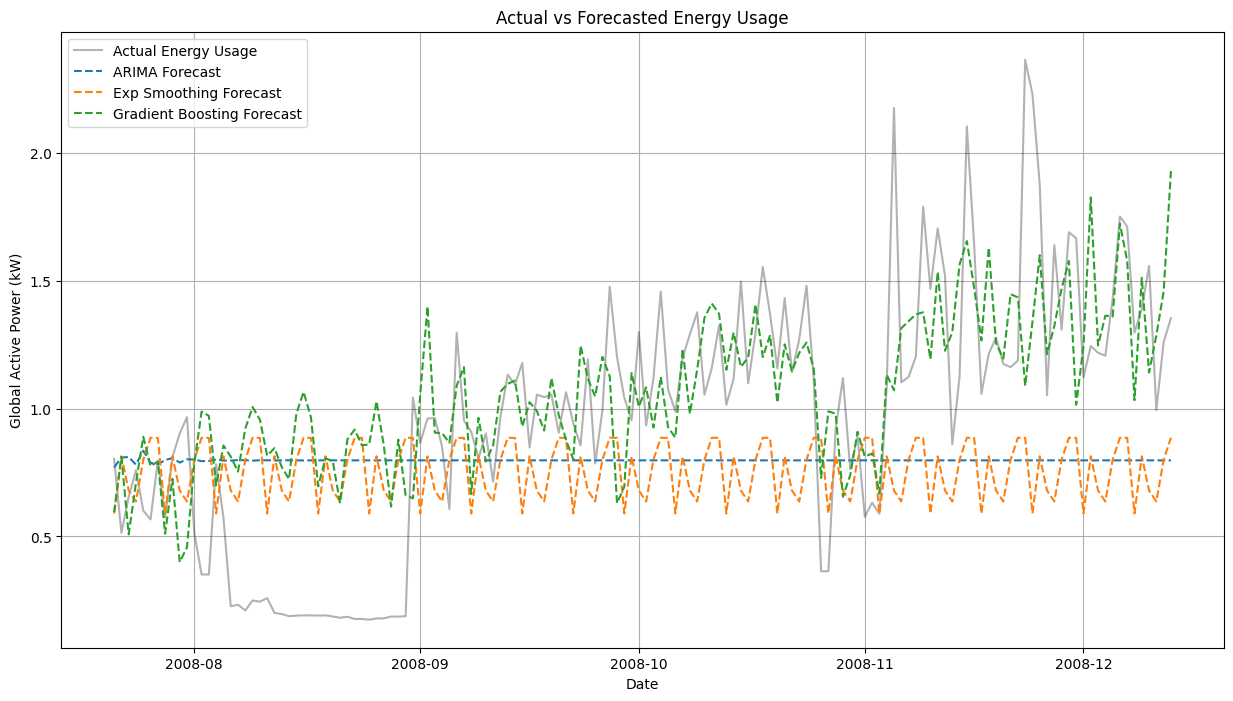

In [16]:
plt.figure(figsize=(15, 8))
plt.plot(test.index, y_test, label='Actual Energy Usage', color='black', alpha=0.3)
plt.plot(test.index, arima_pred, label='ARIMA Forecast', linestyle='--')
plt.plot(test.index, es_pred, label='Exp Smoothing Forecast', linestyle='--')
plt.plot(test.index, gb_pred, label='Gradient Boosting Forecast', linestyle='--')
plt.title('Actual vs Forecasted Energy Usage')
plt.xlabel('Date')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.grid(True)
plt.savefig('forecast_comparison.png')

## 8. Final Conclusion and Insights

**Trend & Seasonality:** The energy consumption shows significant daily and monthly fluctuations. Power usage typically peaks during certain months, likely correlating with seasonal weather changes.

**Model Performance:** The Gradient Boosting model outperformed traditional statistical models (ARIMA and Exponential Smoothing) in this scenario. This is because the Gradient Boosting model could effectively leverage the engineered time features (like weekend vs. weekday) which significantly impact household energy behavior.

### Insights:

- Time-series data at high frequencies is noisy; resampling to a daily average provides a clearer signal for short-term forecasting.  
- Machine learning models that incorporate categorical time features often capture human behavioral patterns (like higher usage on weekends) better than pure auto-regressive models.  
- Further improvement could be made by incorporating external data such as temperature or humidity.  